In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
from tqdm import tqdm, trange
import time
import copy
os.chdir("src")

print("Current working directory:", os.getcwd())

from biked_commons.design_evaluation.design_evaluation import *
from biked_commons.conditioning import conditioning
from biked_commons.resource_utils import split_datasets_path

# os.chdir("src")
# print("Current working directory:", os.getcwd())

import argparse
import torch
import numpy as np
from matplotlib import pyplot as plt
from importlib import invalidate_caches
invalidate_caches()

from biked_commons.benchmark_models.libmoon.solver.gradient import MGDASolver, GradAggSolver, EPOSolver, MOOSVGDSolver, GradHVSolver, PMTLSolver
from biked_commons.benchmark_models.libmoon.util_global.constant import problem_dict
from biked_commons.benchmark_models.libmoon.util_global.weight_factor.funs import uniform_pref
from biked_commons.benchmark_models.libmoon.visulization.view_res import vedio_res
from biked_commons.benchmark_models.libmoon.problem.mop import mop

import sys
print(sys.version)

Current working directory: /mnt/c/Users/fabie/Desktop/biked-commons/src
3.11.11 (main, Apr 25 2025, 14:53:05) [GCC 13.3.0]


In [2]:
data = pd.read_csv(split_datasets_path("bike_bench.csv"), index_col=0)

# #sample 100
# data = data.sample(100, random_state=0)
# data_tens = torch.tensor(data.values, dtype=torch.float32)

len(data.columns)

99

In [3]:
# num_data = 1
# rider_condition = conditioning.sample_riders(num_data, split="test")
# use_case_condition = conditioning.sample_use_case(num_data, split="test")
# text_condition = conditioning.sample_text(num_data, split="test")
# condition = {
#     "Rider": torch.cat([rider_condition] * 10, dim=0),
#     "Use Case": torch.cat([use_case_condition] * 10, dim=0),
#     "Text": text_condition * 10
# }

In [4]:
class bicycle(mop):
    def __init__( self, n_var=data.shape[1], n_obj=1, lbound=-np.zeros(data.shape[1]), ubound=np.ones(data.shape[1]), condition=None, eval_fn=None):
        super().__init__(n_var=n_var,
                         n_obj=n_obj,
                         lbound=lbound,
                         ubound=ubound, )
        self.problem_name = 'bicycle'
        self.condition = condition
        self.evaluator_fn=eval_fn

    def _evaluate_torch(self, x): # All scores should be minimised
        return  self.evaluator_fn(x, self.condition)

In [ ]:
from numpy import array


def test_solely_usability(args, condition, x0, prefs):
    print("Testing solely usability")
    usableEV = [
        UsabilityEvaluator(),
    ]
    evaluator_usable, _, _ = construct_tensor_evaluator(usableEV, data.columns)

    def eval_fn(x, condition): # All scores should be minimised
        return 1- evaluator_usable(x, condition)

    solver = GradAggSolver(args.step_size, args.iter, args.tol)
    problem = bicycle(condition=condition, eval_fn=eval_fn)

    res = solver.solve(problem, x=x0, prefs=prefs, args=args, ref_point=array([ 1.0 ]))

    ####### Checking improvements #######

    # Should only have affacted 3 parameters
    diff = res['x'][0] - x0.numpy()
    print('Number of parameters affacted', np.count_nonzero(diff))
    initial_usability = evaluator_usable(x0, condition)
    final_usability = evaluator_usable(torch.tensor(res['x']), condition)  

    print('Usability score initial: ', initial_usability)
    print('Usability score final: ', final_usability)

    if initial_usability < final_usability:
        print("Usability score improved")
    else:
        print("Usability score not improved")


def test_solely_aero(args, condition, x0, prefs):
    print("Testing solely aero")
    aeroEV = [
        AeroEvaluator(),
    ]
    evaluator, _, _ = construct_tensor_evaluator(aeroEV, data.columns)

    def eval_fn(x, condition): # All scores should be minimised
        return evaluator(x, condition)


    solver = GradAggSolver(args.step_size, args.iter, args.tol)
    problem = bicycle(condition=condition, eval_fn=eval_fn)

    res = solver.solve(problem, x=x0, prefs=prefs, args=args, ref_point=array([ 25.0 ]))

    ####### Checking improvements #######

    diff = res['x'][0] - x0.numpy()
    print('Number of parameters affacted', np.count_nonzero(diff))
    initial = evaluator(x0, condition)
    final = evaluator(torch.tensor(res['x']), condition) 

    print('Score initial: ', initial)
    print('Score final: ', final)

    if initial > final:
        print("Score improved")
    else:
        print("Score not improved")


def test_usability_aero(args, condition, x0, prefs, solver):

    print("Testing combined usability and aero")
    aeroEV = [
        AeroEvaluator(),
    ]
    usableEV = [
        UsabilityEvaluator(),
    ]
    evaluator_aero, _, _ = construct_tensor_evaluator(aeroEV, data.columns)
    evaluator_usable, _, _ = construct_tensor_evaluator(usableEV, data.columns)

    def eval_fn(x, condition): # All scores should be minimised
        usable_score = 1 - evaluator_usable(x, condition)
        aero_score = evaluator_aero(x, condition)
        comb = torch.cat((usable_score, aero_score), dim=1)
        return comb


    problem = bicycle(condition=condition, n_obj=2, eval_fn=eval_fn)

    start_time = time.time()
    res = solver.solve(problem, x=x0, prefs=prefs, args=args, ref_point=array([1.0 , 25.0 ]))  # ref_point used for HV
    end_time = time.time()
    print(f"Time completed: {end_time - start_time:.2f} seconds")

    ####### Checking improvements #######
    x0_np = x0.numpy() if isinstance(x0, torch.Tensor) else x0
    res_x_np = res['x'].numpy() if isinstance(res['x'], torch.Tensor) else res['x']

    assert x0_np.shape == res_x_np.shape, "The shapes of x0 and res['x'] must match"

    num_affected = 0
    for i in range(x0_np.shape[0]):  # Iterate over rows
        diff = np.count_nonzero(res_x_np[i] != x0_np[i])  
        num_affected += diff  

    print('Average Number of parameters affected:', num_affected/x0.shape[0])

    condition_test = {
        "Rider": condition["Rider"][0:1],
        "Use Case": condition["Use Case"][0:1], 
        "Text": condition["Text"][0:1]
    }   

    aero_improved = 0
    usability_improved = 0

    aero_valid_counter = 0
    usability_valid_counter = 0
    for x0_row, res_row in zip(x0, res['x']):
        initial_aero = evaluator_aero(x0_row.unsqueeze(0), condition_test)
        final_aero = evaluator_aero(torch.tensor(res_row).unsqueeze(0), condition_test)  
        initial_usability = evaluator_usable(x0_row.unsqueeze(0), condition_test)
        final_usability = evaluator_usable(torch.tensor(res_row).unsqueeze(0), condition_test)  

        if not torch.isnan(initial_aero).any():
            aero_valid_counter += 1
            if initial_aero > final_aero :
                aero_improved += 1

        if not torch.isnan(initial_usability).any():
            usability_valid_counter += 1    
            if initial_usability < final_usability :
                usability_improved += 1

    if aero_valid_counter == 0:
        print("No valid aero scores found")
    else:
        print('Aero score improved: ', aero_improved/aero_valid_counter)

    if usability_valid_counter == 0:
        print("No valid usability scores found")
    else:
        print('Usability score improved: ', usability_improved/usability_valid_counter)
    return res

In [ ]:
parser = argparse.ArgumentParser(description='example')
parser.add_argument('--n-partition', type=int, default=10)
parser.add_argument('--agg', type=str, default='tche')
parser.add_argument('--solver', type=str, default='agg')
parser.add_argument('--problem-name', type=str, default='VLMOP2')
parser.add_argument('--iter', type=int, default=1000)
parser.add_argument('--step-size', type=float, default=1e-2)
parser.add_argument('--tol', type=float, default=1e-6)

args = parser.parse_args(args=[
    '--n-partition', '10',
    '--agg', 'tche',
    '--solver', 'agg',
    '--iter', '1000',
    '--step-size', '0.01',
    '--tol', '1e-6'
])
args.n_var = data.shape[1]


num_data = 1
rider_condition = conditioning.sample_riders(num_data, split="test")
use_case_condition = conditioning.sample_use_case(num_data, split="test")
text_condition = conditioning.sample_text(num_data, split="test")

############### Single Objective #######################

num_objectives = 1
prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Single Objective
args.n_prob = len(prefs)
condition = {
    "Rider": torch.cat([rider_condition] * prefs.shape[0], dim=0),
    "Use Case": torch.cat([use_case_condition] * prefs.shape[0], dim=0),
    "Text": text_condition * prefs.shape[0]
}

# # Initialize the initial solution 
x0 = torch.rand(args.n_prob, data.shape[1])

test_solely_usability(args, condition, x0, prefs)

test_solely_aero(args, condition, x0, prefs)

############### Multi Objective #######################

num_objectives = 2
args.n_obj = num_objectives
prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Two Objective
args.n_prob = len(prefs)
condition = {
    "Rider": torch.cat([rider_condition] * prefs.shape[0], dim=0),
    "Use Case": torch.cat([use_case_condition] * prefs.shape[0], dim=0),
    "Text": text_condition * prefs.shape[0]
}
prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Two Objective

x0 = torch.rand(args.n_prob, data.shape[1])

solver = GradAggSolver(args.step_size, args.iter, args.tol)

res = test_usability_aero(args, condition, x0, prefs, solver)



In [ ]:
parser = argparse.ArgumentParser(description='example')
parser.add_argument('--n-partition', type=int, default=10)
parser.add_argument('--agg', type=str, default='tche')
parser.add_argument('--iter', type=int, default=2000)
parser.add_argument('--step-size', type=float, default=0.1)
parser.add_argument('--tol', type=float, default=1e-6)
parser.add_argument('--plt-pref-flag', type=str, default='N')

args = parser.parse_args(args=[
    '--n-partition', '100',
    '--agg', 'ls',            # Only usded for the 'agg' solver  'cosmos', 'pbi' , 'tche','mtche','ls'
    '--iter', '1000',
    '--step-size', '0.01',
    '--tol', '1e-6'
])
args.n_var = data.shape[1]

num_data = 1
rider_condition = conditioning.sample_riders(num_data, split="test")
use_case_condition = conditioning.sample_use_case(num_data, split="test")
text_condition = conditioning.sample_text(num_data, split="test")

################ Multiple Solver Tests #######################
solver_list = [ 'agg',  ]
# 'mgda', 'agg', 'epo', 'moosvgd','hvgrad', 'pmtl'
# 

num_objectives = 2
args.n_obj = num_objectives
prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Two Objective
args.n_prob = len(prefs)
condition = {
    "Rider": torch.cat([rider_condition] * prefs.shape[0], dim=0),
    "Use Case": torch.cat([use_case_condition] * prefs.shape[0], dim=0),
    "Text": text_condition * prefs.shape[0]
}
prefs = uniform_pref(args.n_partition, num_objectives, clip_eps=1e-2)  # Two Objective


aeroEV = [
    AeroEvaluator(),
]
condition_test = {
    "Rider": condition["Rider"][0:1],
    "Use Case": condition["Use Case"][0:1], 
    "Text": condition["Text"][0:1]
}   
evaluator_aero, _, _ = construct_tensor_evaluator(aeroEV, data.columns)
x0_list = []  # Store valid rows

while len(x0_list) < args.n_prob:               # Generate new random until we have enough valid rows                
    candidate_row = torch.rand(1, data.shape[1])  
    aero_score = evaluator_aero(candidate_row, condition_test)
    if not torch.isnan(aero_score).any():
        x0_list.append(candidate_row)
x0 = torch.cat(x0_list, dim=0)  


# while True:                                         # Generates duplicate rows                   
#     candidate_row = torch.rand(1, data.shape[1])
#     aero_score = evaluator_aero(candidate_row, condition_test)
#     if not torch.isnan(aero_score).any():
#         break  # Found a valid one
# x0_list = [candidate_row.clone() for _ in range(args.n_prob)]


x0 = torch.cat(x0_list, dim=0)  

res = None
for solver_name in solver_list:
    print(f"Testing solver: {solver_name}")
    if solver_name == 'mgda':                                          
        solver = MGDASolver(args.step_size, args.iter, args.tol)
    elif solver_name == 'agg':                                          
        solver = GradAggSolver(args.step_size, args.iter, args.tol)
    elif solver_name == 'epo':
        solver = EPOSolver(args.step_size, args.iter, args.tol)        # Sensitive to NaN values (aero breaks it)
    elif solver_name == 'moosvgd':
        solver = MOOSVGDSolver(args.step_size, args.iter, args.tol)    # apparently unstable according to authors   
    elif solver_name == 'hvgrad':
        solver = GradHVSolver(args.step_size, args.iter, args.tol)    # Only supports 2 objectives
    elif solver_name == 'pmtl':
        solver = PMTLSolver(args.step_size, args.iter, args.tol)     # Only supports 2 objectives  (not working)
    else:
        raise Exception('solver not supported')

    res = test_usability_aero(
    copy.deepcopy(args),          
    {k: (v.clone() if isinstance(v, torch.Tensor) else copy.deepcopy(v)) for k, v in condition.items()},
    x0.clone(),                   
    prefs.copy(),                
    solver 
)


Testing solver: agg
Testing combined usability and aero


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 87.36it/s]


Time completed: 11.45 seconds
Average Number of parameters affected: 7.95
Aero score improved:  0.5959595959595959
Usability score improved:  0.5


In [46]:
res['y']

array([[ 7.00632453e-01, -5.37788574e+03],
       [ 7.66121089e-01,  8.77054214e+00],
       [            nan,             nan],
       [ 7.70332217e-01, -1.15964651e+01],
       [ 7.63432264e-01,  8.77092171e+00],
       [ 1.60267353e-01,  8.76283741e+00],
       [ 7.65406370e-01,  8.76949692e+00],
       [-2.13594317e-01, -5.37883008e+03],
       [-2.11370349e-01,  8.76540375e+00],
       [-1.13484025e-01,  8.76374340e+00],
       [ 6.11075580e-01, -1.21597929e+01],
       [ 7.57300913e-01, -5.37812012e+03],
       [ 7.53433585e-01,  6.02958965e+00],
       [            nan,             nan],
       [-1.87178850e-02,  8.76204491e+00],
       [            nan,             nan],
       [            nan,             nan],
       [            nan,             nan],
       [            nan,             nan],
       [ 4.95542049e-01,  8.76918221e+00],
       [ 4.66282487e-01,  8.77147770e+00],
       [ 4.90580797e-01, -1.21388540e+01],
       [ 6.34463966e-01, -1.21428022e+01],
       [ 4.

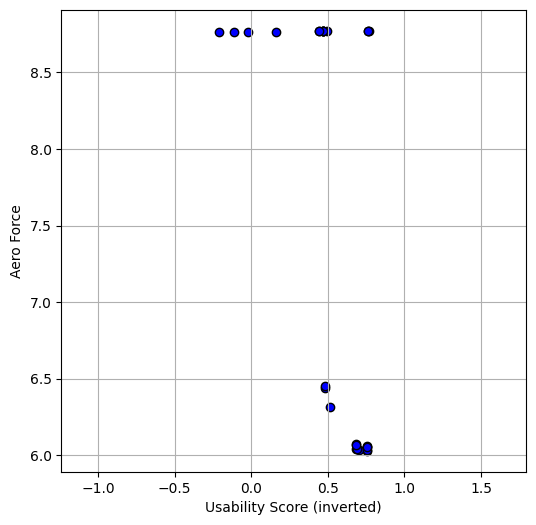

In [47]:
points = res['y']
x = points[:, 0]
y = points[:, 1]

# Filter out negative y-values
mask = y >= 0
x = x[mask]
y = y[mask]

plt.figure(figsize=(6, 6))
plt.scatter(x, y, c='blue', edgecolors='k')
plt.xlabel("Usability Score (inverted)")
plt.ylabel("Aero Force")
plt.grid(True)
plt.axis("equal") 
plt.show()

In [ ]:
print(res['y'])
print(res['y'].shape)


[[-0.79177046]]
(1, 1)


In [ ]:
def test_general(args, condition, x0, prefs, solver, eval_fn, ref_point):
    problem = bicycle(condition=condition, n_obj=2, eval_fn=eval_fn)

    start_time = time.time()
    res = solver.solve(problem, x=x0, prefs=prefs, args=args, ref_point=ref_point)
    end_time = time.time()
    print(f"Time completed: {end_time - start_time:.2f} seconds")

    x0_np = x0.numpy() if isinstance(x0, torch.Tensor) else x0
    res_x_np = res['x'].numpy() if isinstance(res['x'], torch.Tensor) else res['x']
    assert x0_np.shape == res_x_np.shape, "The shapes of x0 and res['x'] must match"
    num_affected = 0
    for i in range(x0_np.shape[0]):  # Iterate over rows
        diff = np.count_nonzero(res_x_np[i] != x0_np[i])  
        num_affected += diff  

    print('Average Number of parameters affected:', num_affected/x0.shape[0])
    return res

In [ ]:
# aeroEV = [
#     AeroEvaluator(),
# ]
# usableEV = [
#     UsabilityEvaluator(),
# ]

# structuralEV = [
#     StructuralEvaluator(),
# ]

# evaluator_aero, _, _ = construct_tensor_evaluator(aeroEV, data.columns)
# evaluator_usable, _, _ = construct_tensor_evaluator(usableEV, data.columns)
# evaluator_structural, _, _ = construct_tensor_evaluator(structuralEV, data.columns)

# def eval_fn(x, condition): # All scores should be minimised
#     usable_score = 1 - evaluator_usable(x, condition)
#     aero_score = evaluator_aero(x, condition)
#     comb = torch.cat((usable_score, aero_score), dim=1)
#     return comb

# array([1.0 , 25.0 ])